In [23]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

## Downloading and loading Dataset

In [24]:
# Linux
!wget http://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip
!unzip -q att_faces.zip -d faces_dataset
!rm att_faces.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.
'rm' is not recognized as an internal or external command,
operable program or batch file.


In [25]:
# Windows
import requests
import zipfile
# 1. Download the file
url = "http://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip"
r = requests.get(url)
with open("att_faces.zip", "wb") as f:
    f.write(r.content)

# 2. Unzip the file
with zipfile.ZipFile("att_faces.zip", "r") as zip_ref:
    zip_ref.extractall("faces_dataset")

# 3. Remove the zip file
os.remove("att_faces.zip")

print("Done!")

Done!


In [26]:
def load_pgm_data(dataset_path='att_faces'):
    images = [] # each row is pixels flattened of a person
    labels = [] # each row is the label of that person
    
    # Get all person directories sorted -- to make sure it's the same every time
    person_dirs = sorted([d for d in os.listdir(dataset_path) 
                         if os.path.isdir(os.path.join(dataset_path, d))])
    
    for person_id, person_dir in enumerate(person_dirs):
        person_path = os.path.join(dataset_path, person_dir) # person_path = dataset_path/person_dir/ == faces_dataset/s1/ 
        
        # Get all PGM files in this person's directory
        pgm_files = sorted([f for f in os.listdir(person_path) 
                           if f.endswith('.pgm')])
        
        # Load each image
        for pgm_file in pgm_files:
            img_path = os.path.join(person_path, pgm_file) # path to actual image
            img = Image.open(img_path)
            img_array = np.array(img).flatten()  # Flatten to 1D as requested in assignment
            # print(len(img_array))
            images.append(img_array)
            labels.append(person_id)
    
    return np.array(images), np.array(labels)

# Load the data
X, y = load_pgm_data('faces_dataset')
print(f"X shape: {X.shape}, y shape: {y.shape}") # 40 x 10 = 400 images each 10304 pixels
print(f"Dataset shape: {X.shape}")
print(f"Number of people: {len(np.unique(y))}")
print(f"Images per person: {len(y) // len(np.unique(y))}")


X shape: (400, 10304), y shape: (400,)
Dataset shape: (400, 10304)
Number of people: 40
Images per person: 10


## Doing PCA

We got the data points. Each Person "SAMPLE" is 10304-D. Highly dimensional, can not be plotted.

That's why we need PCA. 

1. Standardization
2. Covariance matrix
3. Singular Value Decomposition (SVD) to get Eigen values and Eigen vectors
4. Sort the Eigen vectors according to the Eigen values
5. Choose top k according to some criteria
6. Project the 10304-D data samples to the k/10304 chosen dimensions

In [35]:
# 0. train_test split-- calculating mean and s.d and getting the principal components form train only to avoid data leakage 
# 0. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, stratify=y, random_state=42
    )

# 1. Standardization 
features_mean = np.mean(X_train, axis=0)
features_std = np.std(X_train, axis=0)
X_train_normalized = (X_train - features_mean) / features_std
X_test_normalized = (X_test - features_mean) / features_std # normalizing test using the train mean to avoid data leakage too
# and we need to have the same center point for all i guess?


#! Note X 400x10304 -- NxD
# 2. covariance matrix: NxD DxN -> NxN -> Dual PCA Trick
# covariance matrix between the samples instead of features because D >> N -> crashes memory    
# --- This is SAMPLE EIGEN VECTORS --- not our used to FEATURE EIGEN VECTORS
S = np.dot(X_train_normalized, X_train_normalized.T) # 400x400

# 3. eigen values and eigen vectors
eigenvalues, eigenvectors = np.linalg.eigh(S) # 400x400

# 4. Sort both eigenvalues and eigenvectors in descending order of eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx] # overriding old array to be of descending order
eigenvectors = eigenvectors[:, idx] # same as above but to keep eig val-vec pair consistent

# Normalizing the eigen vectors so that they are unit vectors ||v|| = 1
norms = np.linalg.norm(eigenvectors, axis=0)
eigenvectors = eigenvectors / norms

Number of components to capture 95% variance: 116


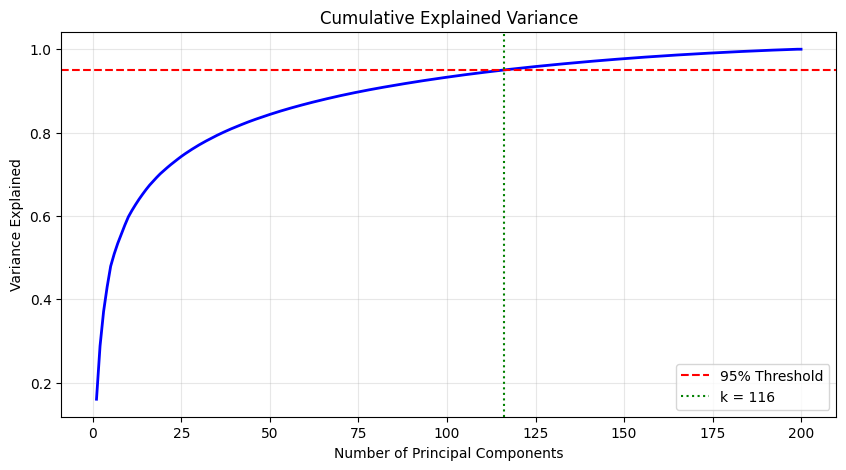

In [36]:
# Proportional Variance: Variance of k/ total variance
# variance measured using the eigen values

# Calculate cumulative explained variance
exp_var_ratio = eigenvalues / np.sum(eigenvalues) # each eigen value "normalized" so taking PV of k is is simply sum
cum_var = np.cumsum(exp_var_ratio) # Cumulative sum so TOP k PV is at index k

# Find how many components we need for 95%
k = np.argmax(cum_var >= 0.95) + 1 # +1 because it returns an index
print(f"Number of components to capture 95% variance: {k}")

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, color='blue', lw=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
plt.axvline(x=k, color='green', linestyle=':', label=f'k = {k}')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
# W for features
# 10304x400  400x400 -> 10304x400 -> FEATURE EIGEN VECTORS: DxN 
W_large = np.dot(X_train_normalized.T, eigenvectors)
W_normalized = W_large / np.linalg.norm(W_large, axis=0)

W_k = W_normalized[:, :k] # eigen vectors

# project TRAIN AND TEST into the k eigen vectors
X_train_reduced = np.dot(X_train_normalized, W_k) # projecting train
X_test_reduced = np.dot(X_test_normalized, W_k) # projecting train
print(f"Original shape: {X.shape}, Reduced shape: {X_train_reduced.shape}")
print(f"Test Original shape: {X_test.shape}, Test Reduced shape: {X_test_reduced.shape}")

Original shape: (400, 10304), Reduced shape: (200, 116)
Test Original shape: (200, 10304), Test Reduced shape: (200, 116)


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def train_and_evaluate(X_train, y_train, X_test, y_test, n_neighbors=3):
    # # 1. Stratified Split
    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=test_size, stratify=y, random_state=42
    # )
    
    # 2. Initialize k-NN
    # n_neighbors=3 is a good starting point for 10 images per person
    # metric='euclidean' or 'cosine' work best for PCA-reduced data
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
    
    # 3. Train (k-NN just stores the data)
    knn.fit(X_train, y_train)
    
    # 4. Predict
    y_pred = knn.predict(X_test)
    
    # 5. Results
    acc = accuracy_score(y_test, y_pred)
    print(f"k-NN Accuracy (n_neighbors={n_neighbors}): {acc:.4f}")
    print("\nDetailed Performance Metrics (Precision, Recall, F1-Score):")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # 5. Confusion Matrix Visualization
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap='Greens')
    plt.title(f'k-NN Confusion Matrix (n_neighbors={n_neighbors})')
    plt.xlabel('Predicted Person ID')
    plt.ylabel('True Person ID')
    plt.show()
    return knn

k-NN Accuracy (n_neighbors=3): 0.8950

Detailed Performance Metrics (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       0.50      1.00      0.67         5
           7       1.00      0.80      0.89         5
           8       0.71      1.00      0.83         5
           9       1.00      0.60      0.75         5
          10       1.00      0.80      0.89         5
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         5
          13       0.83      1.00      0.91         5
          14       1.00      1.00      1.00         5
          15       0.83      1.00   

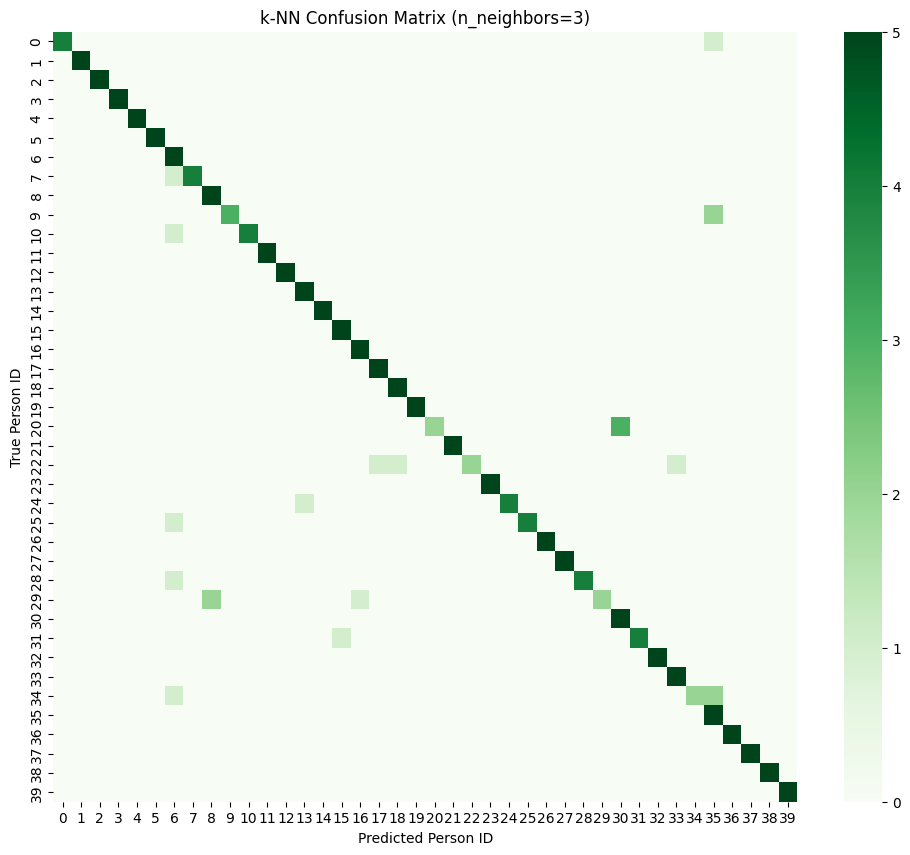

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [39]:
train_and_evaluate(X_train_reduced, y_train, X_test_reduced, y_test, n_neighbors=3)

k-NN Accuracy (n_neighbors=3): 0.8750

Detailed Performance Metrics (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      1.00      1.00         5
           2       1.00      0.60      0.75         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       0.62      1.00      0.77         5
           7       1.00      0.60      0.75         5
           8       0.71      1.00      0.83         5
           9       0.75      0.60      0.67         5
          10       0.50      0.80      0.62         5
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         5
          13       0.71      1.00      0.83         5
          14       1.00      1.00      1.00         5
          15       0.75      0.60   

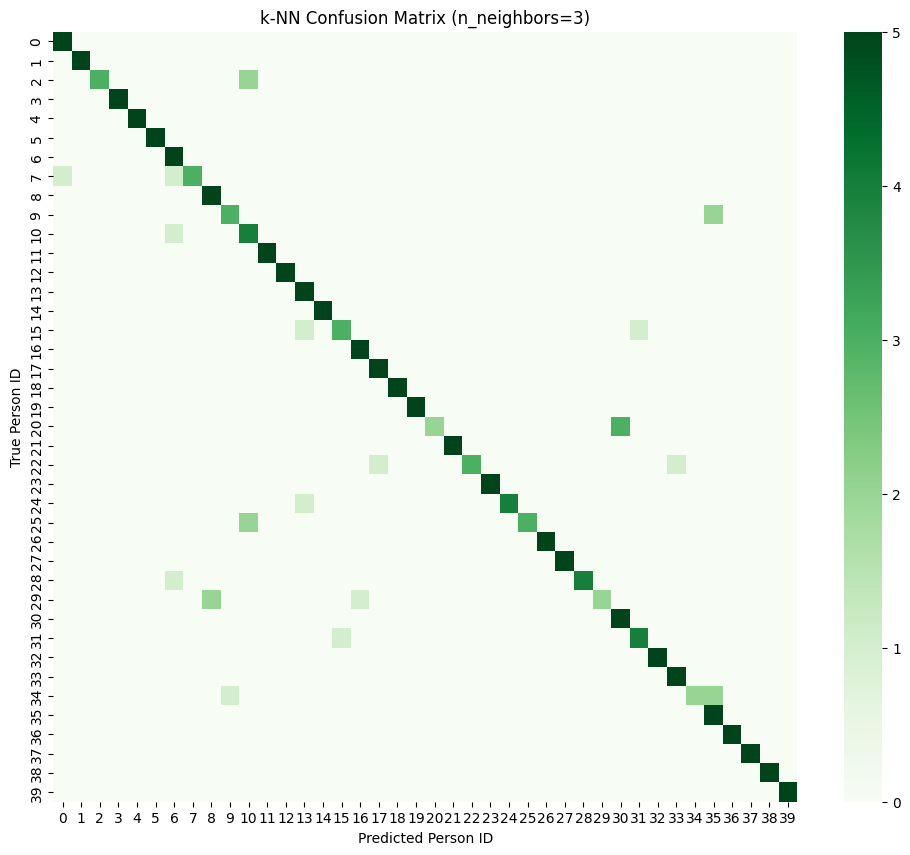

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
train_and_evaluate(X_train, y_train, X_test, y_test, n_neighbors=3)